In [1]:
import mysql.connector
import pandas as pd
import matplotlib.pyplot as plt

# MySQL 연결
conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="class1234",
    database="subway_realestate"
)

print("MySQL 연결 성공!")

MySQL 연결 성공!


In [2]:
query = """
SELECT
    year,
    station_name,
    total_ridership,
    housing_type,
    avg_transaction_amount
FROM station_analysis
WHERE housing_type = '아파트'
  AND year BETWEEN 2022 AND 2025
"""

df = pd.read_sql(query, conn)

print(df.head())
print(df.shape)

   year station_name  total_ridership housing_type  avg_transaction_amount
0  2022           강남       51764650.0          아파트             138289.5918
1  2022         건대입구       25466644.0          아파트              23947.3333
2  2022           교대       22046803.0          아파트             122581.4386
3  2022      구로디지털단지       36820457.0          아파트              37310.3478
4  2022           구의       15143563.0          아파트             116800.6122
(130, 5)


C:\Users\user\AppData\Local\Temp\ipykernel_2456\3722892526.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


d:\data_work\team_project\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 50500 (\N{HANGUL SYLLABLE A}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\data_work\team_project\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 54028 (\N{HANGUL SYLLABLE PA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\data_work\team_project\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 53944 (\N{HANGUL SYLLABLE TEU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\data_work\team_project\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 54217 (\N{HANGUL SYLLABLE PYEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\data_work\team_project\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 44512 (\N{HANGUL SYLLABLE GYUN}) missing from font(s) DejaVu Sa

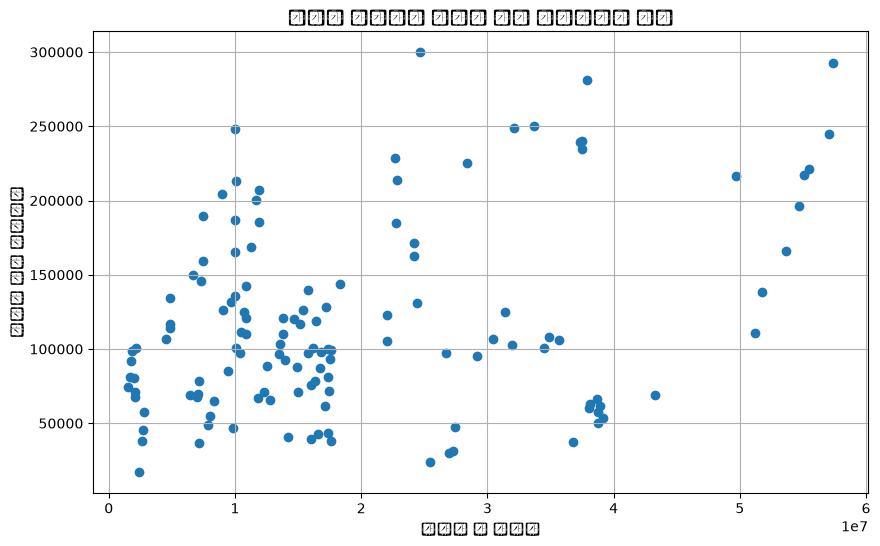

In [3]:
plt.figure(figsize=(10, 6))

plt.scatter(
    df["total_ridership"],
    df["avg_transaction_amount"]
)

plt.xlabel("지하철 총 이용량")
plt.ylabel("아파트 평균 거래금액")
plt.title("지하철 이용량과 아파트 평균 거래금액의 관계")

plt.grid(True)
plt.show()

In [5]:
import mysql.connector
import pandas as pd
import matplotlib.pyplot as plt

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'

# 마이너스 기호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

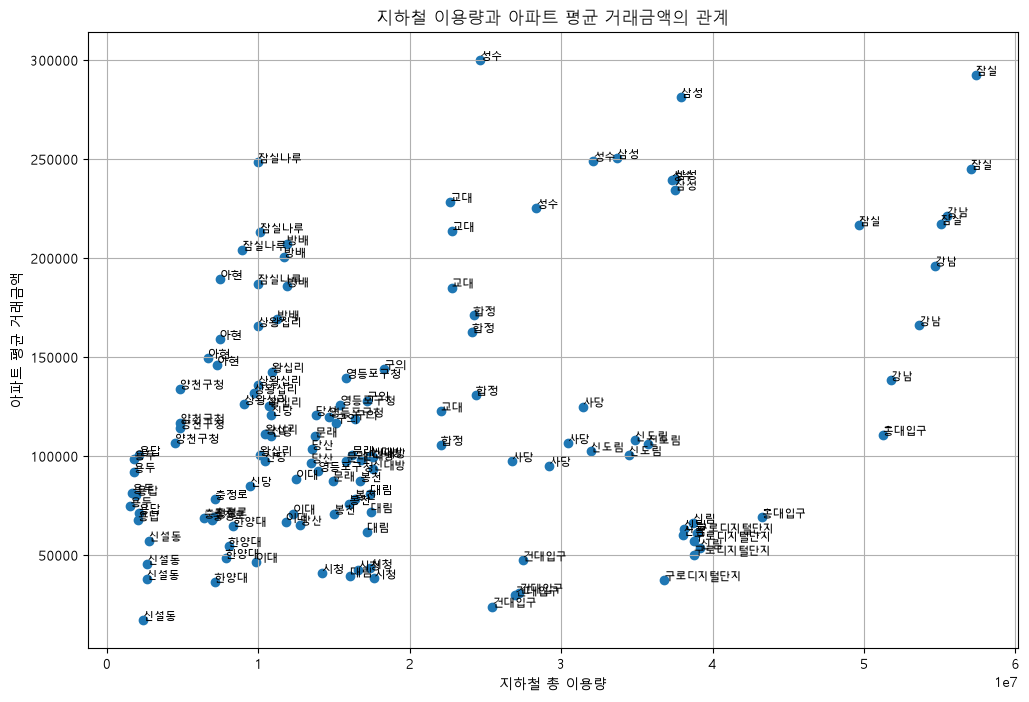

In [6]:
plt.figure(figsize=(12, 8))

plt.scatter(
    df["total_ridership"],
    df["avg_transaction_amount"]
)

for _, row in df.iterrows():
    plt.annotate(
        row["station_name"],
        (row["total_ridership"], row["avg_transaction_amount"]),
        fontsize=8
    )

plt.xlabel("지하철 총 이용량")
plt.ylabel("아파트 평균 거래금액")
plt.title("지하철 이용량과 아파트 평균 거래금액의 관계")

plt.grid(True)
plt.show()

In [7]:
import mysql.connector
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [8]:
year_price = (
    df.groupby("year")["avg_transaction_amount"]
      .mean()
      .reset_index()
)

print(year_price)

   year  avg_transaction_amount
0  2022           103539.245003
1  2023           111696.269736
2  2024           120368.165347
3  2025           135633.680819


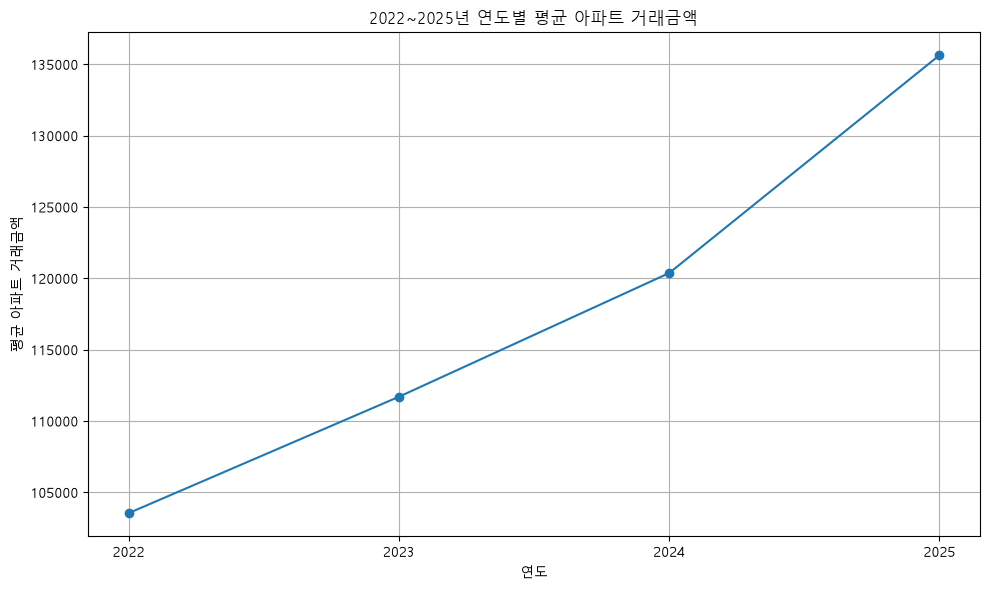

In [9]:
plt.figure(figsize=(10, 6))

plt.plot(
    year_price["year"],
    year_price["avg_transaction_amount"],
    marker="o"
)

plt.xlabel("연도")
plt.ylabel("평균 아파트 거래금액")
plt.title("2022~2025년 연도별 평균 아파트 거래금액")

plt.xticks(year_price["year"])
plt.grid(True)
plt.tight_layout()
plt.show()

In [10]:
year_ridership = (
    df.groupby("year")["total_ridership"]
      .mean()
      .reset_index()
)

print(year_ridership)

   year  total_ridership
0  2022     1.861567e+07
1  2023     2.014100e+07
2  2024     1.966354e+07
3  2025     2.000392e+07


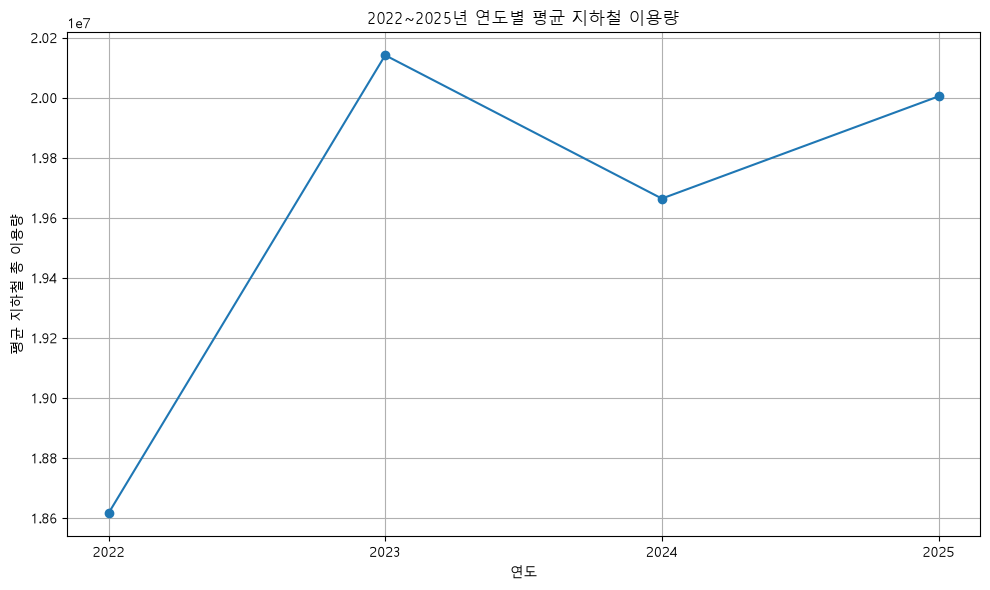

In [11]:
plt.figure(figsize=(10, 6))

plt.plot(
    year_ridership["year"],
    year_ridership["total_ridership"],
    marker="o"
)

plt.xlabel("연도")
plt.ylabel("평균 지하철 총 이용량")
plt.title("2022~2025년 연도별 평균 지하철 이용량")

plt.xticks(year_ridership["year"])
plt.grid(True)
plt.tight_layout()

In [12]:
query_subway = """
SELECT
    year,
    station_name,
    total_ridership
FROM subway_annual
WHERE year BETWEEN 2022 AND 2025
"""

df_subway = pd.read_sql(query_subway, conn)

C:\Users\user\AppData\Local\Temp\ipykernel_2456\2624598321.py:10: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_subway = pd.read_sql(query_subway, conn)


In [13]:
year_ridership = (
    df_subway.groupby("year")["total_ridership"]
             .mean()
             .reset_index()
)

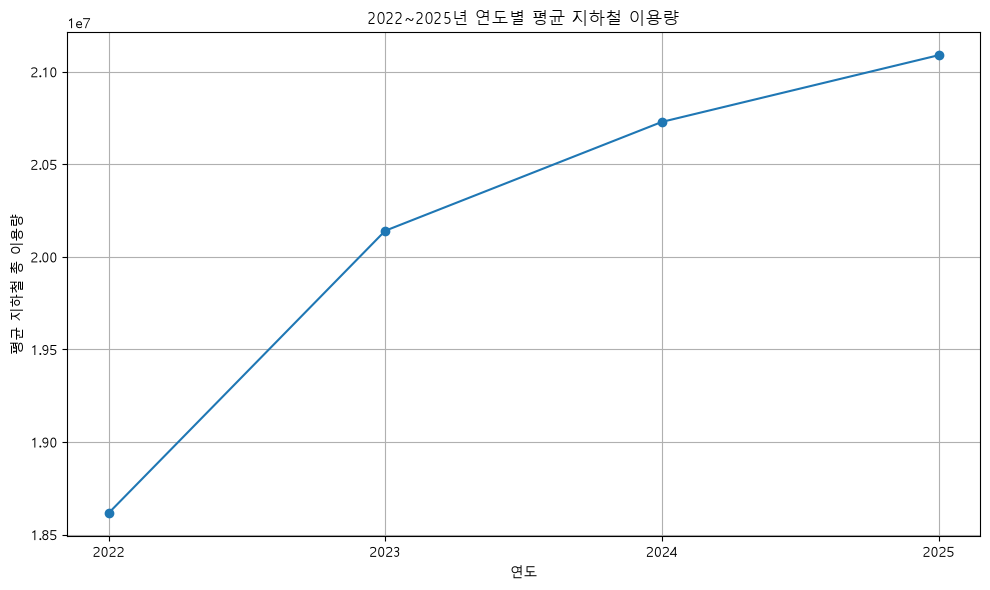

In [14]:
plt.figure(figsize=(10, 6))

plt.plot(
    year_ridership["year"],
    year_ridership["total_ridership"],
    marker="o"
)

plt.xlabel("연도")
plt.ylabel("평균 지하철 총 이용량")
plt.title("2022~2025년 연도별 평균 지하철 이용량")

plt.xticks(year_ridership["year"])
plt.grid(True)

plt.tight_layout()
plt.show()

In [15]:
print(year_ridership)

   year  total_ridership
0  2022     1.861567e+07
1  2023     2.014100e+07
2  2024     2.072894e+07
3  2025     2.108918e+07


In [16]:
year_price = (
    df.groupby("year")["avg_transaction_amount"]
      .mean()
      .reset_index()
)

print(year_price)

   year  avg_transaction_amount
0  2022           103539.245003
1  2023           111696.269736
2  2024           120368.165347
3  2025           135633.680819


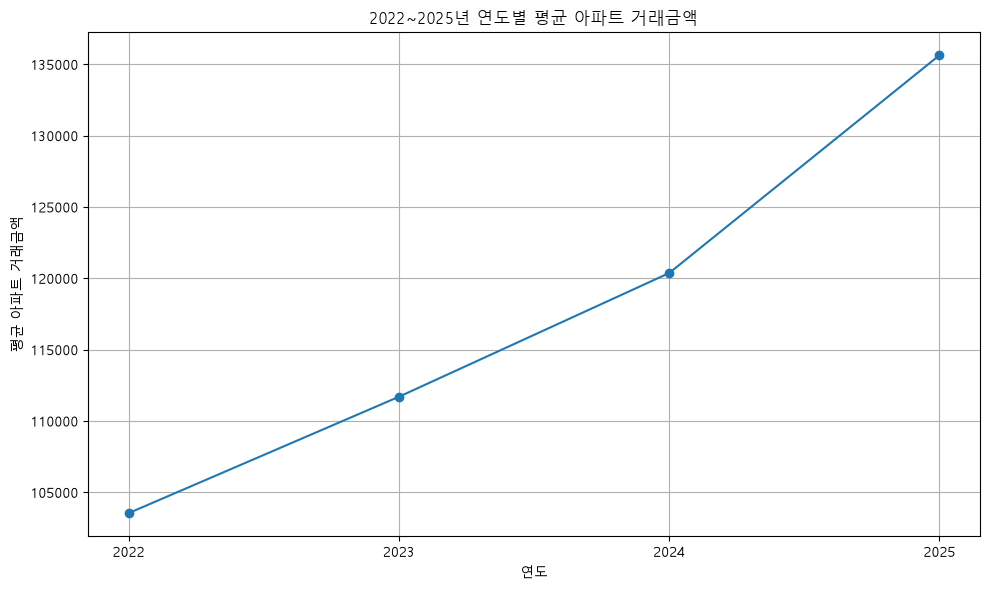

In [17]:
plt.figure(figsize=(10, 6))

plt.plot(
    year_price["year"],
    year_price["avg_transaction_amount"],
    marker="o"
)

plt.xlabel("연도")
plt.ylabel("평균 아파트 거래금액")
plt.title("2022~2025년 연도별 평균 아파트 거래금액")

plt.xticks(year_price["year"])
plt.grid(True)

plt.tight_layout()
plt.show()

In [18]:
year_change = pd.merge(
    year_ridership,
    year_price,
    on="year"
)

print(year_change)

   year  total_ridership  avg_transaction_amount
0  2022     1.861567e+07           103539.245003
1  2023     2.014100e+07           111696.269736
2  2024     2.072894e+07           120368.165347
3  2025     2.108918e+07           135633.680819


In [19]:
year_change["ridership_change"] = (
    year_change["total_ridership"]
    .pct_change() * 100
)

year_change["price_change"] = (
    year_change["avg_transaction_amount"]
    .pct_change() * 100
)

print(year_change)

   year  total_ridership  avg_transaction_amount  ridership_change  \
0  2022     1.861567e+07           103539.245003               NaN   
1  2023     2.014100e+07           111696.269736          8.193822   
2  2024     2.072894e+07           120368.165347          2.919115   
3  2025     2.108918e+07           135633.680819          1.737851   

   price_change  
0           NaN  
1      7.878196  
2      7.763818  
3     12.682353  


In [20]:
year_change["ridership_index"] = (
    year_change["total_ridership"]
    / year_change["total_ridership"].iloc[0]
    * 100
)

year_change["price_index"] = (
    year_change["avg_transaction_amount"]
    / year_change["avg_transaction_amount"].iloc[0]
    * 100
)

print(year_change)

   year  total_ridership  avg_transaction_amount  ridership_change  \
0  2022     1.861567e+07           103539.245003               NaN   
1  2023     2.014100e+07           111696.269736          8.193822   
2  2024     2.072894e+07           120368.165347          2.919115   
3  2025     2.108918e+07           135633.680819          1.737851   

   price_change  ridership_index  price_index  
0           NaN       100.000000   100.000000  
1      7.878196       108.193822   107.878196  
2      7.763818       111.352124   116.253663  
3     12.682353       113.287258   130.997363  


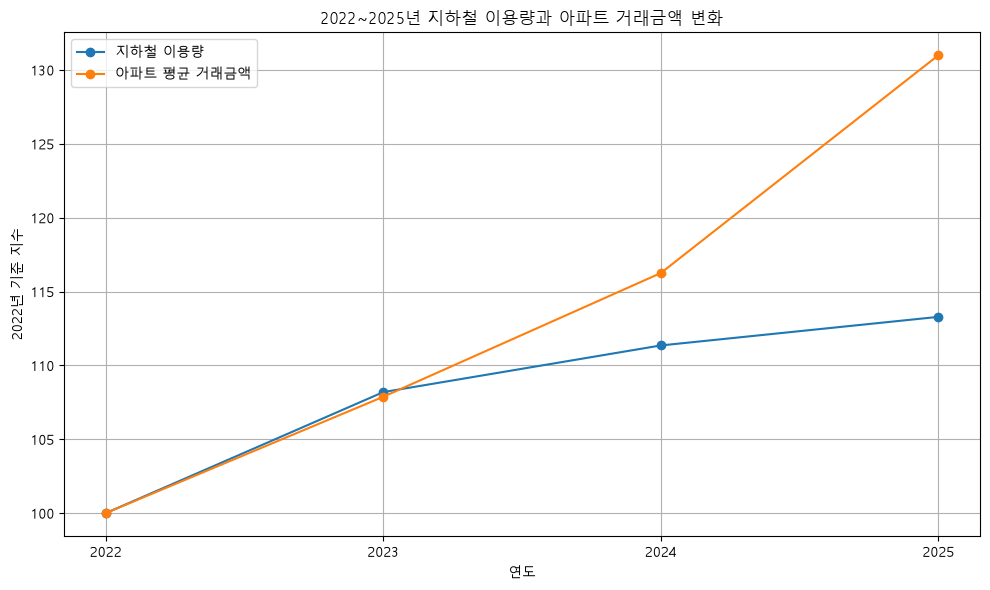

In [21]:
plt.figure(figsize=(10, 6))

plt.plot(
    year_change["year"],
    year_change["ridership_index"],
    marker="o",
    label="지하철 이용량"
)

plt.plot(
    year_change["year"],
    year_change["price_index"],
    marker="o",
    label="아파트 평균 거래금액"
)

plt.xlabel("연도")
plt.ylabel("2022년 기준 지수")
plt.title("2022~2025년 지하철 이용량과 아파트 거래금액 변화")
plt.xticks(year_change["year"])

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [22]:
year_change["ridership_index"] = (
    year_change["total_ridership"]
    / year_change["total_ridership"].iloc[0]
    * 100
)

year_change["price_index"] = (
    year_change["avg_transaction_amount"]
    / year_change["avg_transaction_amount"].iloc[0]
    * 100
)

In [23]:
df_2025 = df[
    (df["year"] == 2025) &
    (df["housing_type"] == "아파트")
].copy()

print(df_2025.head())

     year station_name  total_ridership housing_type  avg_transaction_amount
98   2025           강남       55447943.0          아파트             221158.1986
99   2025         건대입구       27453162.0          아파트              47337.1429
100  2025           교대       22682783.0          아파트             228365.5604
101  2025      구로디지털단지       38957929.0          아파트              61388.1770
102  2025           구의       18318969.0          아파트             143942.3560


In [24]:
print(df_2025["station_name"].nunique())
print(len(df_2025))

32
32


In [25]:
print("전체 지하철 역 개수:", df_subway["station_name"].nunique())
print("2025년 아파트 역 개수:", df_2025["station_name"].nunique())

전체 지하철 역 개수: 33
2025년 아파트 역 개수: 32


In [27]:
print("2025년 아파트 역 개수:", df_2025["station_name"].nunique())

2025년 아파트 역 개수: 32


In [26]:
subway_2025 = df_subway[df_subway["year"] == 2025]

print("2025년 지하철 역 개수:", subway_2025["station_name"].nunique())

2025년 지하철 역 개수: 33


In [28]:
subway_stations = set(
    subway_2025["station_name"].unique()
)

real_estate_stations = set(
    df_2025["station_name"].unique()
)

missing_stations = subway_stations - real_estate_stations

print("부동산 데이터가 없는 역:")
print(missing_stations)

부동산 데이터가 없는 역:
{'홍대입구'}


# 2025년 아파트 32개 역 나오는이유
-> 2025년에는 홍대입구 역의 아파트 매매 거래가 없음

In [29]:
print(len(df_2025))
print(df_2025["station_name"].nunique())

32
32


In [30]:
ridership_median = df_2025["total_ridership"].median()
price_median = df_2025["avg_transaction_amount"].median()

print("지하철 이용량 중앙값:", ridership_median)
print("아파트 평균 거래금액 중앙값:", price_median)

지하철 이용량 중앙값: 16459370.0
아파트 평균 거래금액 중앙값: 120745.718


In [31]:
def classify_station(row):
    if (
        row["total_ridership"] >= ridership_median
        and row["avg_transaction_amount"] >= price_median
    ):
        return "이용량↑ 가격↑"

    elif (
        row["total_ridership"] >= ridership_median
        and row["avg_transaction_amount"] < price_median
    ):
        return "이용량↑ 가격↓"

    elif (
        row["total_ridership"] < ridership_median
        and row["avg_transaction_amount"] >= price_median
    ):
        return "이용량↓ 가격↑"

    else:
        return "이용량↓ 가격↓"


df_2025["group"] = df_2025.apply(classify_station, axis=1)

In [32]:
group_count = df_2025["group"].value_counts()

print(group_count)

group
이용량↑ 가격↑    8
이용량↑ 가격↓    8
이용량↓ 가격↓    8
이용량↓ 가격↑    8
Name: count, dtype: int64


In [33]:
for group, data in df_2025.groupby("group"):
    print("\n====================")
    print(group)
    print("====================")

    print(
        data[
            ["station_name",
             "total_ridership",
             "avg_transaction_amount"]
        ]
        .sort_values("total_ridership", ascending=False)
        .to_string(index=False)
    )


이용량↑ 가격↑
station_name  total_ridership  avg_transaction_amount
          잠실       57378276.0             292570.2639
          강남       55447943.0             221158.1986
          삼성       37906767.0             281381.9945
          성수       37304777.0             239427.0510
          사당       31415671.0             125051.0259
          합정       24145490.0             162639.0244
          교대       22682783.0             228365.5604
          구의       18318969.0             143942.3560

이용량↑ 가격↓
station_name  total_ridership  avg_transaction_amount
     구로디지털단지       38957929.0              61388.1770
          신림       38711576.0              66334.1643
         신도림       34858127.0             107944.2557
        건대입구       27453162.0              47337.1429
          시청       17646652.0              38203.3333
         신대방       17379615.0              99822.2960
          대림       17378124.0              80854.2045
          봉천       16725190.0              87369.7428

이용량↓ 가격

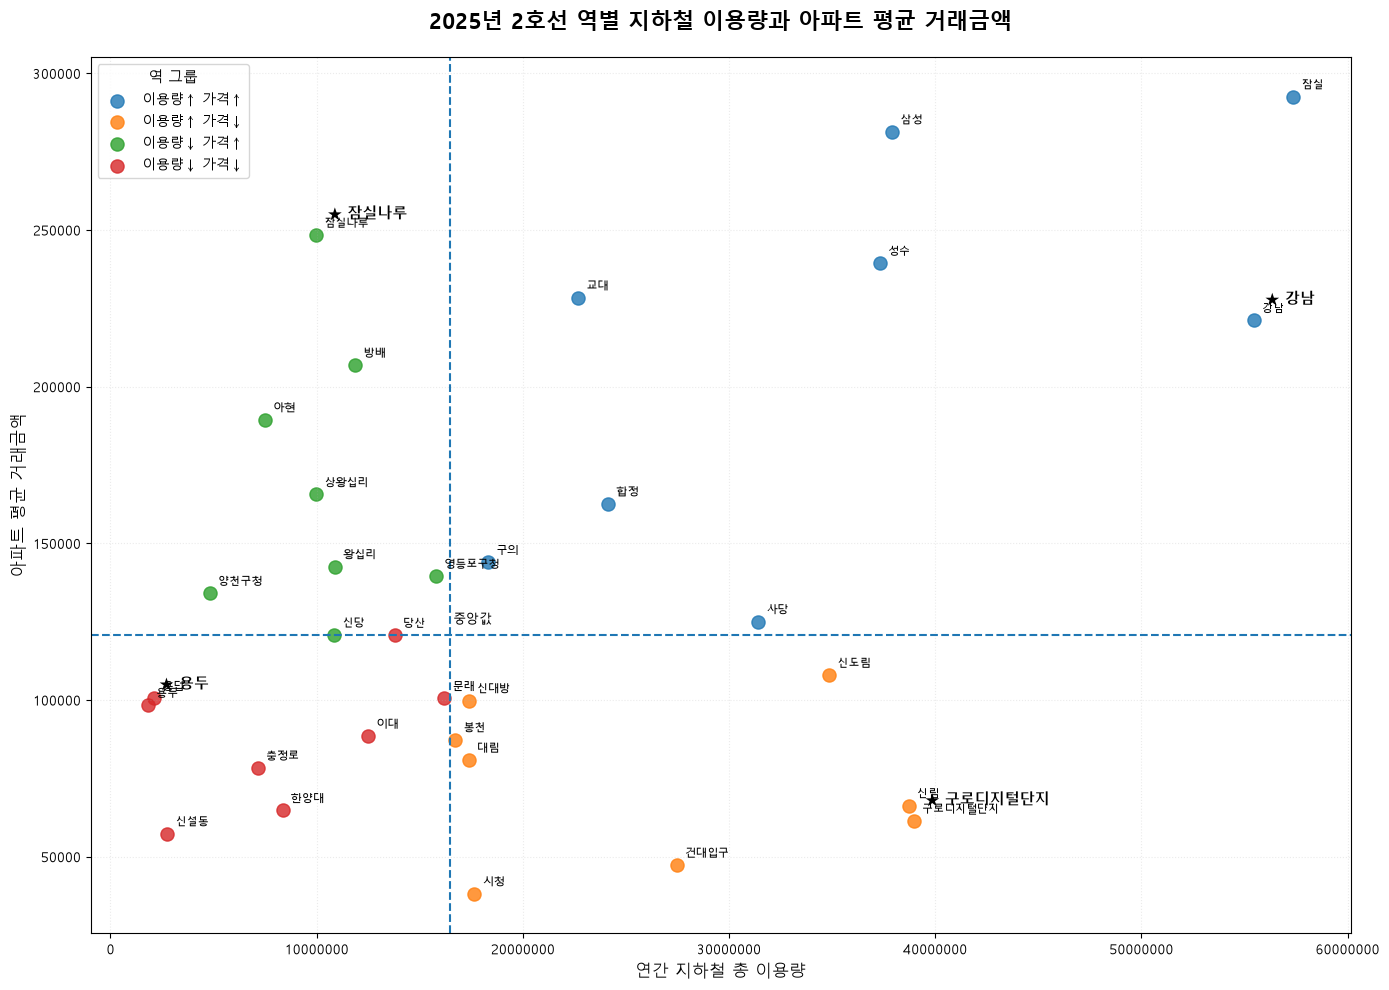

In [34]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 10))

# 그룹별 데이터
groups = {
    "이용량↑ 가격↑": df_2025[df_2025["group"] == "이용량↑ 가격↑"],
    "이용량↑ 가격↓": df_2025[df_2025["group"] == "이용량↑ 가격↓"],
    "이용량↓ 가격↑": df_2025[df_2025["group"] == "이용량↓ 가격↑"],
    "이용량↓ 가격↓": df_2025[df_2025["group"] == "이용량↓ 가격↓"]
}

# 그룹별 산점도
for group_name, data in groups.items():
    plt.scatter(
        data["total_ridership"],
        data["avg_transaction_amount"],
        s=90,
        alpha=0.8,
        label=group_name
    )

# 중앙값 기준선
plt.axvline(
    ridership_median,
    linestyle="--",
    linewidth=1.5
)

plt.axhline(
    price_median,
    linestyle="--",
    linewidth=1.5
)

# 모든 역 이름 표시
for _, row in df_2025.iterrows():
    plt.annotate(
        row["station_name"],
        (
            row["total_ridership"],
            row["avg_transaction_amount"]
        ),
        xytext=(6, 6),
        textcoords="offset points",
        fontsize=8
    )

# 대표 역 강조
highlight_stations = ["강남", "구로디지털단지", "잠실나루", "용두"]

for _, row in df_2025[
    df_2025["station_name"].isin(highlight_stations)
].iterrows():

    plt.annotate(
        f'★ {row["station_name"]}',
        (
            row["total_ridership"],
            row["avg_transaction_amount"]
        ),
        xytext=(8, 12),
        textcoords="offset points",
        fontsize=11,
        fontweight="bold"
    )

# 중앙값 위치에 설명 추가
plt.text(
    ridership_median * 1.01,
    price_median * 1.03,
    "중앙값",
    fontsize=9
)

# 제목과 축
plt.title(
    "2025년 2호선 역별 지하철 이용량과 아파트 평균 거래금액",
    fontsize=16,
    fontweight="bold",
    pad=20
)

plt.xlabel(
    "연간 지하철 총 이용량",
    fontsize=12
)

plt.ylabel(
    "아파트 평균 거래금액",
    fontsize=12
)

# 축 숫자 보기 좋게
plt.ticklabel_format(
    style="plain",
    axis="both"
)

# 격자
plt.grid(
    alpha=0.25,
    linestyle=":"
)

# 범례
plt.legend(
    title="역 그룹",
    fontsize=10,
    title_fontsize=11,
    loc="upper left"
)

plt.tight_layout()
plt.show()

지금까지 2025년 아파트 매매 값만 분석 완료 
이제부터 2022 ~ 2025 4개 유형, 전세, 월세, 매매 모두 분석

In [37]:
query_all = """
SELECT
    year,
    station_name,
    transaction_amount,
    housing_type,
    transaction_type,
    deposit,
    rent
FROM real_estate
WHERE year BETWEEN 2022 AND 2025
"""

df_all = pd.read_sql(query_all, conn)

print(df_all.head())
print(df_all.columns)
print(df_all.shape)

C:\Users\user\AppData\Local\Temp\ipykernel_2456\3880221500.py:14: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_all = pd.read_sql(query_all, conn)


   year station_name  transaction_amount housing_type transaction_type  \
0  2025           시청             27000.0          아파트               매매   
1  2025           시청             27000.0          아파트               매매   
2  2025           시청             27000.0          아파트               매매   
3  2024           시청             55000.0          아파트               매매   
4  2024           시청             55000.0          아파트               매매   

   deposit  rent  
0      NaN   NaN  
1      NaN   NaN  
2      NaN   NaN  
3      NaN   NaN  
4      NaN   NaN  
Index(['year', 'station_name', 'transaction_amount', 'housing_type',
       'transaction_type', 'deposit', 'rent'],
      dtype='str')
(1411374, 7)


In [38]:
print("주택유형:")
print(df_all["housing_type"].unique())

print("\n거래유형:")
print(df_all["transaction_type"].unique())

print("\n연도:")
print(df_all["year"].unique())

주택유형:
<StringArray>
['아파트', '오피스텔', '단독다가구', '연립다세대']
Length: 4, dtype: str

거래유형:
<StringArray>
['매매', '전세', '월세']
Length: 3, dtype: str

연도:
[2025 2024 2022 2023]


In [39]:
price_column = {
    "매매": "transaction_amount",
    "전세": "deposit",
    "월세": "rent"
}

years = [2022, 2023, 2024, 2025]

housing_types = [
    "아파트",
    "연립다세대",
    "단독다가구",
    "오피스텔"
]

transaction_types = [
    "매매",
    "전세",
    "월세"
]

In [40]:
real_estate_summary = []

for year in years:

    for housing_type in housing_types:

        for transaction_type in transaction_types:

            price_col = price_column[transaction_type]

            temp = df_all[
                (df_all["year"] == year) &
                (df_all["housing_type"] == housing_type) &
                (df_all["transaction_type"] == transaction_type)
            ].copy()

            # 가격 컬럼 숫자로 변환
            temp[price_col] = pd.to_numeric(
                temp[price_col],
                errors="coerce"
            )

            # 결측치 제거
            temp = temp.dropna(
                subset=[price_col]
            )

            # 0 이하 제거
            temp = temp[
                temp[price_col] > 0
            ]

            if len(temp) == 0:
                continue

            # 역별 평균 가격
            station_avg = (
                temp
                .groupby("station_name")[price_col]
                .mean()
                .reset_index()
            )

            station_avg["year"] = year
            station_avg["housing_type"] = housing_type
            station_avg["transaction_type"] = transaction_type

            station_avg = station_avg.rename(
                columns={
                    price_col: "avg_price"
                }
            )

            real_estate_summary.append(
                station_avg
            )

In [41]:
df_price = pd.concat(
    real_estate_summary,
    ignore_index=True
)

print(df_price.head())
print(df_price.shape)

  station_name      avg_price  year housing_type transaction_type
0           강남  138289.591837  2022          아파트               매매
1         건대입구   23947.333333  2022          아파트               매매
2           교대  122581.438596  2022          아파트               매매
3      구로디지털단지   37310.347826  2022          아파트               매매
4           구의  116800.612245  2022          아파트               매매
(1383, 5)


In [42]:
print(df_subway.columns)

Index(['year', 'station_name', 'total_ridership'], dtype='str')


In [43]:
df_analysis = pd.merge(
    df_price,
    df_subway[
        [
            "year",
            "station_name",
            "total_ridership"
        ]
    ],
    on=[
        "year",
        "station_name"
    ],
    how="inner"
)

print(df_analysis.head())
print(df_analysis.shape)

  station_name      avg_price  year housing_type transaction_type  \
0           강남  138289.591837  2022          아파트               매매   
1         건대입구   23947.333333  2022          아파트               매매   
2           교대  122581.438596  2022          아파트               매매   
3      구로디지털단지   37310.347826  2022          아파트               매매   
4           구의  116800.612245  2022          아파트               매매   

   total_ridership  
0       51764650.0  
1       25466644.0  
2       22046803.0  
3       36820457.0  
4       15143563.0  
(1383, 6)


In [44]:
results = []

for year in years:

    for housing_type in housing_types:

        for transaction_type in transaction_types:

            temp = df_analysis[
                (df_analysis["year"] == year) &
                (df_analysis["housing_type"] == housing_type) &
                (df_analysis["transaction_type"] == transaction_type)
            ].copy()

            if len(temp) < 3:
                continue

            # 중앙값
            ridership_median = temp[
                "total_ridership"
            ].median()

            price_median = temp[
                "avg_price"
            ].median()

            # 그룹 분류
            temp["group"] = np.select(
                [
                    (temp["total_ridership"] >= ridership_median) &
                    (temp["avg_price"] >= price_median),

                    (temp["total_ridership"] >= ridership_median) &
                    (temp["avg_price"] < price_median),

                    (temp["total_ridership"] < ridership_median) &
                    (temp["avg_price"] >= price_median)
                ],
                [
                    "이용량↑ 가격↑",
                    "이용량↑ 가격↓",
                    "이용량↓ 가격↑"
                ],
                default="이용량↓ 가격↓"
            )

            # 상관계수
            correlation = temp[
                "total_ridership"
            ].corr(
                temp["avg_price"]
            )

            temp["correlation"] = correlation

            results.append(temp)
            

In [45]:
df_result = pd.concat(
    results,
    ignore_index=True
)

print(df_result.head())
print(df_result.shape)

  station_name      avg_price  year housing_type transaction_type  \
0           강남  138289.591837  2022          아파트               매매   
1         건대입구   23947.333333  2022          아파트               매매   
2           교대  122581.438596  2022          아파트               매매   
3      구로디지털단지   37310.347826  2022          아파트               매매   
4           구의  116800.612245  2022          아파트               매매   

   total_ridership     group  correlation  
0       51764650.0  이용량↑ 가격↑     0.248126  
1       25466644.0  이용량↑ 가격↓     0.248126  
2       22046803.0  이용량↑ 가격↑     0.248126  
3       36820457.0  이용량↑ 가격↓     0.248126  
4       15143563.0  이용량↑ 가격↑     0.248126  
(1383, 8)


In [46]:
combination_check = (
    df_result[
        [
            "year",
            "housing_type",
            "transaction_type"
        ]
    ]
    .drop_duplicates()
    .sort_values(
        [
            "year",
            "housing_type",
            "transaction_type"
        ]
    )
)

print(combination_check.to_string(index=False))

 year housing_type transaction_type
 2022        단독다가구               매매
 2022        단독다가구               월세
 2022        단독다가구               전세
 2022          아파트               매매
 2022          아파트               월세
 2022          아파트               전세
 2022        연립다세대               매매
 2022        연립다세대               월세
 2022        연립다세대               전세
 2022         오피스텔               매매
 2022         오피스텔               월세
 2022         오피스텔               전세
 2023        단독다가구               매매
 2023        단독다가구               월세
 2023        단독다가구               전세
 2023          아파트               매매
 2023          아파트               월세
 2023          아파트               전세
 2023        연립다세대               매매
 2023        연립다세대               월세
 2023        연립다세대               전세
 2023         오피스텔               매매
 2023         오피스텔               월세
 2023         오피스텔               전세
 2024        단독다가구               매매
 2024        단독다가구               월세
 2024        단독다가구          

In [47]:
print("전체 분석 조합 수:", len(combination_check))

전체 분석 조합 수: 48


In [48]:
print(
    combination_check.groupby("year").size()
)

year
2022    12
2023    12
2024    12
2025    12
dtype: int64


In [49]:
correlation_summary = (
    df_result[
        [
            "year",
            "housing_type",
            "transaction_type",
            "correlation"
        ]
    ]
    .drop_duplicates()
    .sort_values(
        [
            "year",
            "housing_type",
            "transaction_type"
        ]
    )
)

print(
    correlation_summary.to_string(index=False)
)

 year housing_type transaction_type  correlation
 2022        단독다가구               매매     0.591111
 2022        단독다가구               월세     0.476327
 2022        단독다가구               전세     0.210566
 2022          아파트               매매     0.248126
 2022          아파트               월세     0.181571
 2022          아파트               전세     0.280117
 2022        연립다세대               매매     0.126275
 2022        연립다세대               월세     0.517914
 2022        연립다세대               전세     0.213385
 2022         오피스텔               매매    -0.117826
 2022         오피스텔               월세     0.253140
 2022         오피스텔               전세     0.184492
 2023        단독다가구               매매     0.452832
 2023        단독다가구               월세     0.454867
 2023        단독다가구               전세     0.070078
 2023          아파트               매매     0.340544
 2023          아파트               월세     0.205590
 2023          아파트               전세     0.268589
 2023        연립다세대               매매     0.106682
 2023        연립다세대  

In [50]:
correlation_overall = (
    df_result
    .groupby(
        [
            "housing_type",
            "transaction_type"
        ]
    )["correlation"]
    .mean()
    .reset_index()
    .sort_values(
        "correlation",
        ascending=False
    )
)

print(
    correlation_overall.to_string(index=False)
)

housing_type transaction_type  correlation
       단독다가구               매매     0.571823
       단독다가구               월세     0.440564
         아파트               매매     0.344038
         아파트               전세     0.291450
       연립다세대               월세     0.255935
        오피스텔               월세     0.233164
         아파트               월세     0.204542
        오피스텔               전세     0.136686
       단독다가구               전세     0.118012
       연립다세대               전세     0.099693
       연립다세대               매매     0.095330
        오피스텔               매매    -0.101580


In [51]:
housing_correlation = (
    df_result
    .groupby("housing_type")["correlation"]
    .mean()
    .reset_index()
    .sort_values(
        "correlation",
        ascending=False
    )
)

print(
    housing_correlation.to_string(index=False)
)

housing_type  correlation
       단독다가구     0.377378
         아파트     0.281740
       연립다세대     0.149513
        오피스텔     0.089994


In [52]:
transaction_correlation = (
    df_result
    .groupby("transaction_type")["correlation"]
    .mean()
    .reset_index()
    .sort_values(
        "correlation",
        ascending=False
    )
)

print(
    transaction_correlation.to_string(index=False)
)

transaction_type  correlation
              월세     0.282165
              매매     0.231888
              전세     0.163741


In [53]:
year_correlation = (
    df_result
    .groupby("year")["correlation"]
    .mean()
    .reset_index()
)

print(
    year_correlation.to_string(index=False)
)

 year  correlation
 2022     0.263709
 2023     0.188277
 2024     0.229167
 2025     0.222703


In [55]:
import matplotlib.pyplot as plt
import numpy as np

# 한글 폰트 설정 (Windows)
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False


def plot_quadrant(data, year, housing_type, transaction_type):

    # 조건에 맞는 데이터만 선택
    temp = data[
        (data["year"] == year) &
        (data["housing_type"] == housing_type) &
        (data["transaction_type"] == transaction_type)
    ].copy()

    # 데이터가 없는 경우
    if len(temp) == 0:
        print("해당 조건의 데이터가 없습니다.")
        return

    # 중앙값 계산
    ridership_median = temp["total_ridership"].median()
    price_median = temp["avg_price"].median()

    # 상관계수 계산
    correlation = temp[
        "total_ridership"
    ].corr(
        temp["avg_price"]
    )

    # 그래프 크기
    plt.figure(figsize=(14, 10))

    # 그룹별 점 찍기
    for group, group_data in temp.groupby("group"):

        plt.scatter(
            group_data["total_ridership"],
            group_data["avg_price"],
            s=100,
            alpha=0.8,
            label=group
        )

    # 세로 중앙선
    plt.axvline(
        ridership_median,
        linestyle="--",
        linewidth=1.5
    )

    # 가로 중앙선
    plt.axhline(
        price_median,
        linestyle="--",
        linewidth=1.5
    )

    # 역 이름 표시
    for _, row in temp.iterrows():

        plt.annotate(
            row["station_name"],
            (
                row["total_ridership"],
                row["avg_price"]
            ),
            xytext=(5, 5),
            textcoords="offset points",
            fontsize=9
        )

    # 제목
    plt.title(
        f"{year}년 2호선 {housing_type} {transaction_type}\n"
        f"지하철 이용량과 부동산 가격 4분면 분석",
        fontsize=18,
        fontweight="bold"
    )

    # X축
    plt.xlabel(
        "연간 지하철 총 이용량",
        fontsize=13
    )

    # Y축
    plt.ylabel(
        "평균 가격",
        fontsize=13
    )

    # 상관계수 표시
    plt.text(
        0.02,
        0.96,
        f"Pearson 상관계수 = {correlation:.3f}",
        transform=plt.gca().transAxes,
        fontsize=13,
        fontweight="bold"
    )

    # 숫자를 일반 숫자로 표시
    plt.ticklabel_format(
        style="plain",
        axis="both"
    )

    # 격자
    plt.grid(
        alpha=0.25,
        linestyle=":"
    )

    # 범례
    plt.legend(
        title="역 그룹"
    )

    plt.tight_layout()

    plt.show()

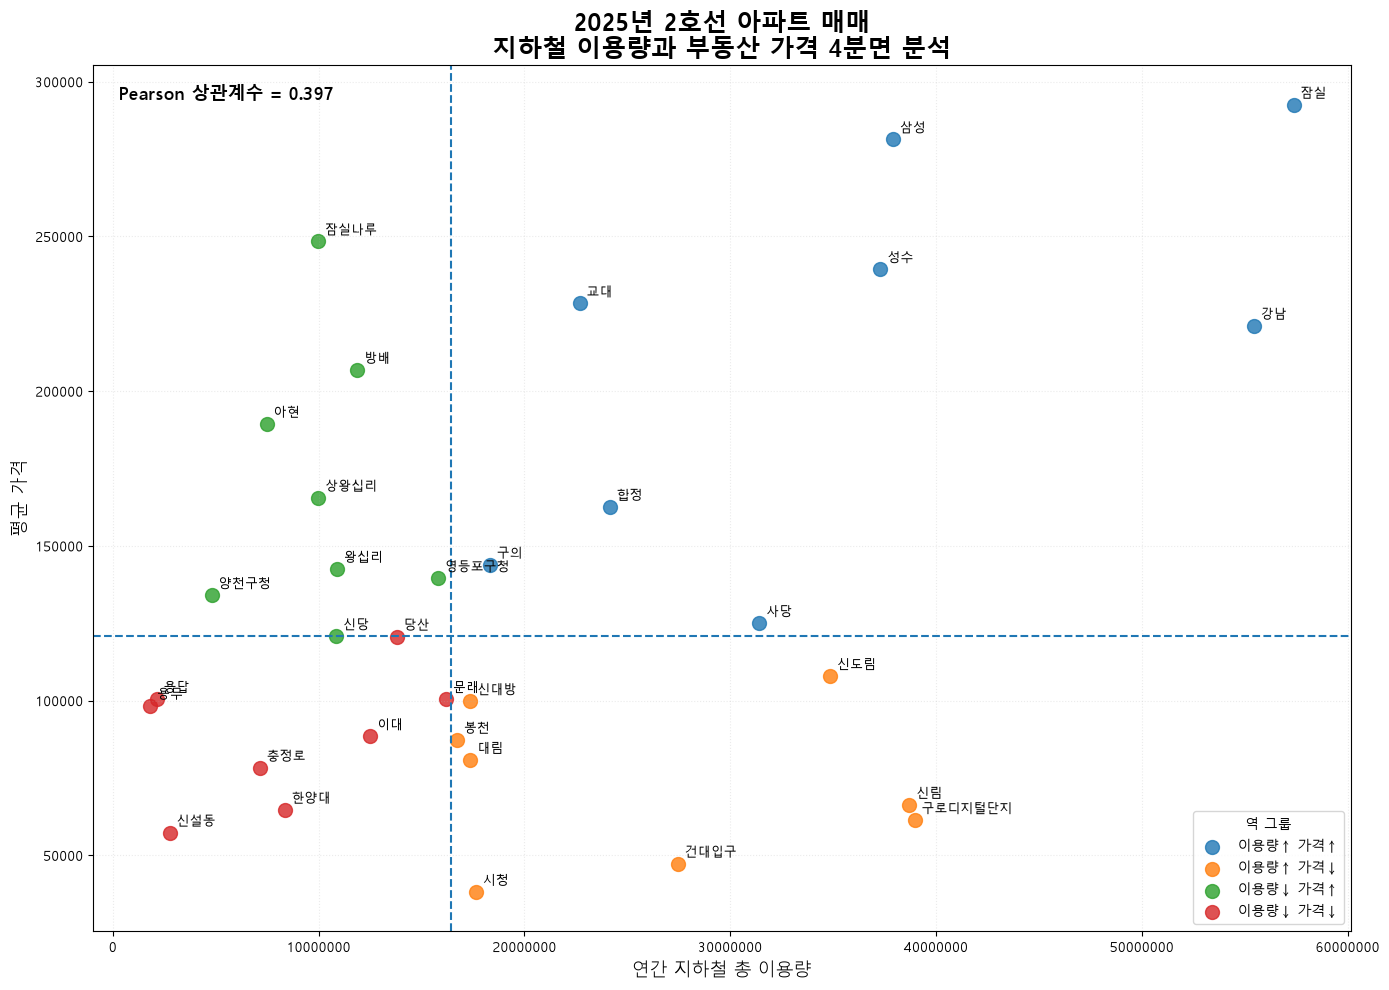

In [56]:
plot_quadrant(
    df_result,
    2025,
    "아파트",
    "매매"
)

In [57]:
import os
import matplotlib.pyplot as plt
import numpy as np

# Windows 한글 폰트
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False


def plot_quadrant(
    data,
    year,
    housing_type,
    transaction_type,
    save_path=None,
    show=True
):

    # 해당 조건 데이터
    temp = data[
        (data["year"] == year) &
        (data["housing_type"] == housing_type) &
        (data["transaction_type"] == transaction_type)
    ].copy()

    # 데이터가 없으면 종료
    if len(temp) == 0:
        print(
            f"데이터 없음: {year} / "
            f"{housing_type} / {transaction_type}"
        )
        return

    # 중앙값
    ridership_median = temp["total_ridership"].median()
    price_median = temp["avg_price"].median()

    # 상관계수
    correlation = temp[
        "total_ridership"
    ].corr(
        temp["avg_price"]
    )

    # 그래프
    fig, ax = plt.subplots(figsize=(12, 9))

    # 그룹별 표시
    for group, group_data in temp.groupby("group"):

        ax.scatter(
            group_data["total_ridership"],
            group_data["avg_price"],
            s=90,
            alpha=0.8,
            label=group
        )

    # 중앙값 기준선
    ax.axvline(
        ridership_median,
        linestyle="--",
        linewidth=1.5
    )

    ax.axhline(
        price_median,
        linestyle="--",
        linewidth=1.5
    )

    # 역 이름
    for _, row in temp.iterrows():

        ax.annotate(
            row["station_name"],
            (
                row["total_ridership"],
                row["avg_price"]
            ),
            xytext=(5, 5),
            textcoords="offset points",
            fontsize=8
        )

    # 제목
    ax.set_title(
        f"{year}년 2호선 {housing_type} {transaction_type}\n"
        f"지하철 이용량 × 부동산 가격 4분면 분석",
        fontsize=17,
        fontweight="bold"
    )

    ax.set_xlabel(
        "연간 지하철 총 이용량",
        fontsize=12
    )

    ax.set_ylabel(
        f"평균 {transaction_type} 가격",
        fontsize=12
    )

    # 상관계수
    ax.text(
        0.02,
        0.96,
        f"Pearson 상관계수 = {correlation:.3f}",
        transform=ax.transAxes,
        fontsize=12,
        fontweight="bold"
    )

    # 숫자 표시
    ax.ticklabel_format(
        style="plain",
        axis="both"
    )

    ax.grid(
        alpha=0.25,
        linestyle=":"
    )

    ax.legend(
        title="역 그룹"
    )

    plt.tight_layout()

    # 저장
    if save_path is not None:
        os.makedirs(
            os.path.dirname(save_path),
            exist_ok=True
        )

        plt.savefig(
            save_path,
            dpi=200,
            bbox_inches="tight"
        )

    # 화면 표시
    if show:
        plt.show()
    else:
        plt.close()

In [58]:
years = [2022, 2023, 2024, 2025]

housing_types = [
    "아파트",
    "연립다세대",
    "단독다가구",
    "오피스텔"
]

transaction_types = [
    "매매",
    "전세",
    "월세"
]


# 저장할 폴더
base_folder = "quadrant_graphs"


graph_count = 0


for year in years:

    for housing_type in housing_types:

        for transaction_type in transaction_types:

            # 파일명
            filename = (
                f"{year}_{housing_type}_{transaction_type}.png"
            )

            save_path = os.path.join(
                base_folder,
                str(year),
                filename
            )

            # 그래프 생성
            plot_quadrant(
                df_result,
                year,
                housing_type,
                transaction_type,
                save_path=save_path,
                show=False
            )

            graph_count += 1


print(f"그래프 생성 완료: {graph_count}개")
print(f"저장 위치: {os.path.abspath(base_folder)}")

그래프 생성 완료: 48개
저장 위치: d:\data_work\team_project\quadrant_graphs


48개 비교해서 핵심 결과 찾기

In [59]:
# 전체 48개 상관계수 보기
correlation_summary = (
    df_result[
        [
            "year",
            "housing_type",
            "transaction_type",
            "correlation"
        ]
    ]
    .drop_duplicates()
    .sort_values(
        "correlation",
        ascending=False
    )
)

print(correlation_summary.to_string(index=False))

 year housing_type transaction_type  correlation
 2025        단독다가구               매매     0.696529
 2022        단독다가구               매매     0.591111
 2024        단독다가구               매매     0.554836
 2022        연립다세대               월세     0.517914
 2022        단독다가구               월세     0.476327
 2024        단독다가구               월세     0.461281
 2023        단독다가구               월세     0.454867
 2023        단독다가구               매매     0.452832
 2025          아파트               매매     0.396965
 2024          아파트               매매     0.393624
 2025          아파트               전세     0.382144
 2025        단독다가구               월세     0.369781
 2023          아파트               매매     0.340544
 2025        연립다세대               월세     0.318384
 2022          아파트               전세     0.280117
 2024         오피스텔               월세     0.271640
 2023          아파트               전세     0.268589
 2022         오피스텔               월세     0.253140
 2022          아파트               매매     0.248126
 2025          아파트  

In [60]:
# 가장 상관 관계가 강한 top 10
top10 = correlation_summary.head(10)

print(top10.to_string(index=False))

 year housing_type transaction_type  correlation
 2025        단독다가구               매매     0.696529
 2022        단독다가구               매매     0.591111
 2024        단독다가구               매매     0.554836
 2022        연립다세대               월세     0.517914
 2022        단독다가구               월세     0.476327
 2024        단독다가구               월세     0.461281
 2023        단독다가구               월세     0.454867
 2023        단독다가구               매매     0.452832
 2025          아파트               매매     0.396965
 2024          아파트               매매     0.393624


In [62]:
# 약하거나 음의 상관관계 확인
bottom10 = (
    correlation_summary
    .sort_values("correlation")
    .head(10)
)

print(bottom10.to_string(index=False))

 year housing_type transaction_type  correlation
 2025         오피스텔               매매    -0.133682
 2022         오피스텔               매매    -0.117826
 2024         오피스텔               매매    -0.087050
 2023         오피스텔               매매    -0.066507
 2025        연립다세대               매매    -0.013815
 2023        연립다세대               월세     0.022984
 2025        단독다가구               전세     0.024480
 2023        연립다세대               전세     0.051520
 2024        연립다세대               전세     0.066625
 2025        연립다세대               전세     0.067241


In [63]:
# 주택유형별로 비교
housing_comparison = (
    correlation_summary
    .groupby("housing_type")["correlation"]
    .mean()
    .sort_values(ascending=False)
)

print(housing_comparison)

housing_type
단독다가구    0.377468
아파트      0.280269
연립다세대    0.150133
오피스텔     0.089528
Name: correlation, dtype: float64


In [64]:
# 매매/전세/월세 비교
transaction_comparison = (
    correlation_summary
    .groupby("transaction_type")["correlation"]
    .mean()
    .sort_values(ascending=False)
)

print(transaction_comparison)

transaction_type
월세    0.283551
매매    0.228037
전세    0.161460
Name: correlation, dtype: float64


In [65]:
# 연도별 변화
year_comparison = (
    correlation_summary
    .groupby("year")["correlation"]
    .mean()
)

print(year_comparison)

year
2022    0.263766
2023    0.184127
2024    0.227846
2025    0.221658
Name: correlation, dtype: float64


In [66]:
group_summary = (
    df_result
    .groupby(
        [
            "year",
            "housing_type",
            "transaction_type",
            "group"
        ]
    )
    .size()
    .reset_index(name="station_count")
)

print(group_summary.to_string(index=False))

 year housing_type transaction_type    group  station_count
 2022        단독다가구               매매 이용량↑ 가격↑             10
 2022        단독다가구               매매 이용량↑ 가격↓              5
 2022        단독다가구               매매 이용량↓ 가격↑              5
 2022        단독다가구               매매 이용량↓ 가격↓              9
 2022        단독다가구               월세 이용량↑ 가격↑              8
 2022        단독다가구               월세 이용량↑ 가격↓              6
 2022        단독다가구               월세 이용량↓ 가격↑              6
 2022        단독다가구               월세 이용량↓ 가격↓              8
 2022        단독다가구               전세 이용량↑ 가격↑              9
 2022        단독다가구               전세 이용량↑ 가격↓              5
 2022        단독다가구               전세 이용량↓ 가격↑              5
 2022        단독다가구               전세 이용량↓ 가격↓              9
 2022          아파트               매매 이용량↑ 가격↑             10
 2022          아파트               매매 이용량↑ 가격↓              7
 2022          아파트               매매 이용량↓ 가격↑              7
 2022          아파트               매매 이용량↓

# 발표 때 언급하면 좋은 대표 5가지

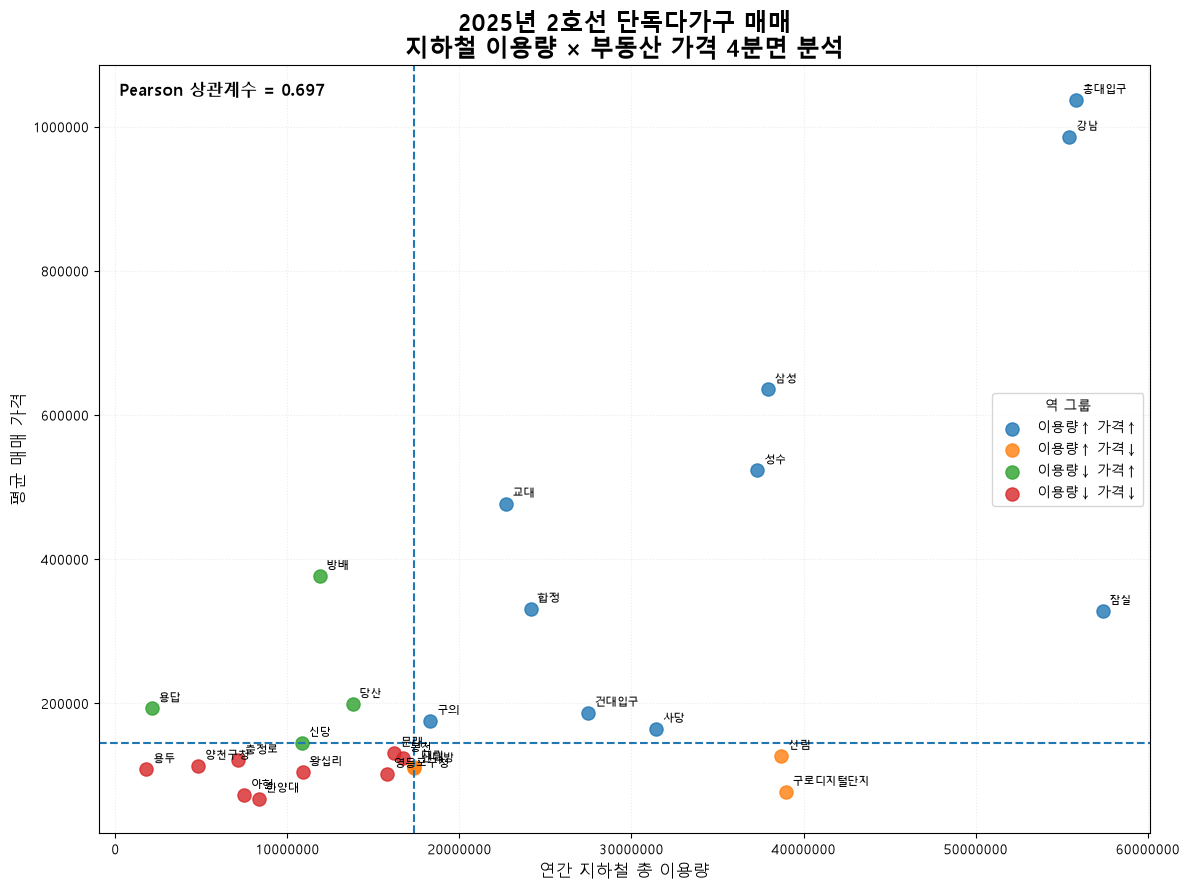

In [67]:
# 2025년 단독다가구 매매 4분면
# 이번 분석에서 가장 강한 상관관계 = 0.697
plot_quadrant(
    df_result,
    2025,
    "단독다가구",
    "매매"
)

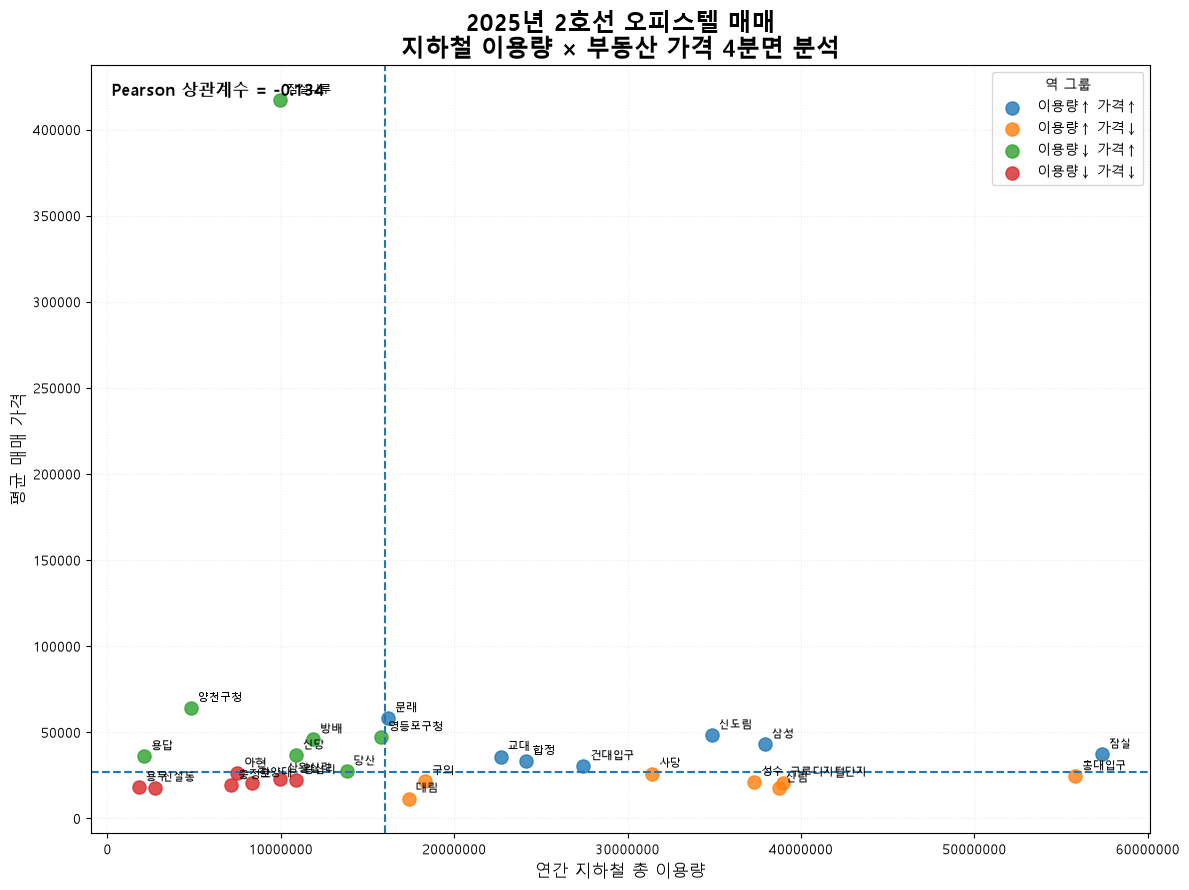

In [68]:
# 2025년 오피스텔 매매 4분면
# 이번 분석에서 가장 약한 상관관계 = -0.134
plot_quadrant(
    df_result,
    2025,
    "오피스텔",
    "매매"
)

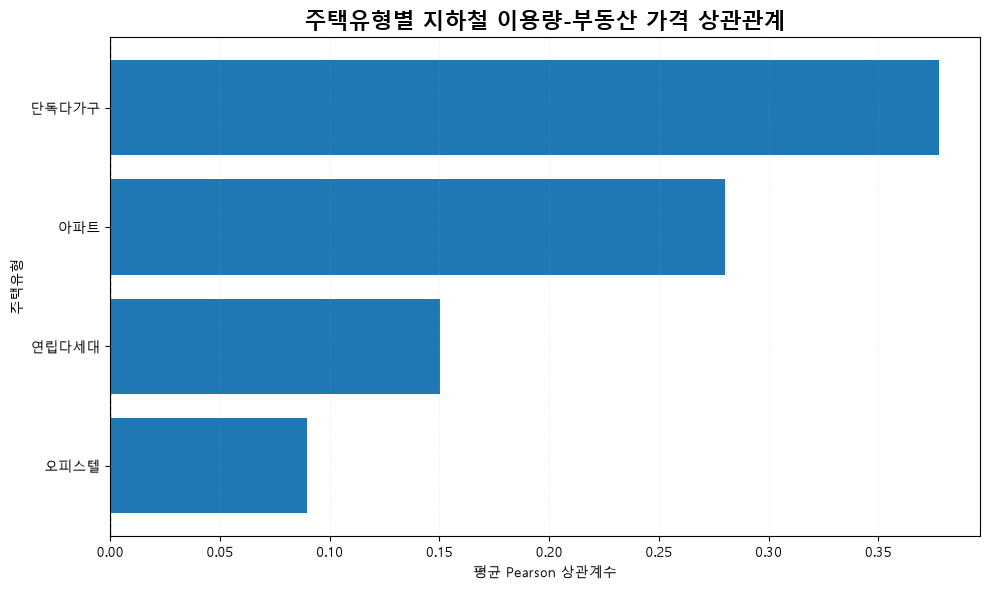

In [69]:
# 주택유형별 상관계수 비교
plt.figure(figsize=(10, 6))

housing_plot = housing_comparison.sort_values()

plt.barh(
    housing_plot.index,
    housing_plot.values
)

plt.axvline(
    0,
    linestyle="--",
    linewidth=1
)

plt.xlabel("평균 Pearson 상관계수")
plt.ylabel("주택유형")
plt.title(
    "주택유형별 지하철 이용량-부동산 가격 상관관계",
    fontsize=16,
    fontweight="bold"
)

plt.grid(
    axis="x",
    alpha=0.25,
    linestyle=":"
)

plt.tight_layout()
plt.show()